### Ennvironment 

- DOKS 1.34.1, FW 1.25.16.3, GPU Driver 6.14.14

- DOKS 1.34.1, FW 1.25.17.7, GPU Driver 6.14.14

### Workload:

- Model - amd/DeepSeek-R1-MXFP4

- Server Image - rocm/sgl-dev:v0.5.9-rocm720-mi35x-20260320

- Input 5600, Output 140

In [2]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
from itertools import product
import numpy
%matplotlib inline  

In [6]:
# Collected Data
df = pd.read_csv("./2026-mi350x8-deepseek.csv")

In [7]:
temp = df['others'].unique()
#print(temp)

In [8]:
def clean (x):
    return x.replace("sglbench-mi350x8-", "")

In [9]:
cases = [x for x in temp if x.startswith("sglbench")]
#cases = [x for x in temp if x.startswith("vllmbench")]
#cases = [x for x in temp] 
# cases

In [10]:
cases = [
    #      'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260315', 
    #     'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260317',
    #      'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320', 
    #      'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320-2',
    #     'sglbench-mi350x8-tp8-sglang-mtp-ep-v0.5.9-rocm720-mi35x-20260320',
    #     'sglbench-mi350x8-tp8-sglang-mtp-ep-v0.5.9-rocm720-mi35x-20260320-2',
    #    'sglbench-mi350x8-tp4-sglang-mtp-v0.5.9-rocm700-mi35x-20260319',
    #'sglbench-mi350x8-tp4-sglang-mtp-v0.5.9-rocm700-mi35x-20260319-2',
    'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320-60-1',
    #'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320-60-2',
    'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320-60-1-fw-1.25.17.07',
    #'sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260320-60-2-fw-1.25.17.07',
    #'sglbench-mi350x8-tp4x2-sglang-mtp-v0.5.9-rocm700-mi35x-20260319-60-1',
    #    'sglbench-mi350x8-tp4-sglang-mtp-v0.5.9-rocm700-mi35x-20260319-60-1',
    #        'sglbench-mi350x8-tp4-sglang-mtp-v0.5.9-rocm700-mi35x-20260319-60-2',
    #'sglbench-mi350x8-tp8-sglang-mtp-ep-v0.5.9-rocm720-mi35x-20260320',
    #'sglbench-mi350x8-tp8-sglang-mtp-ep-v0.5.9-rocm720-mi35x-20260320-2'

 ]

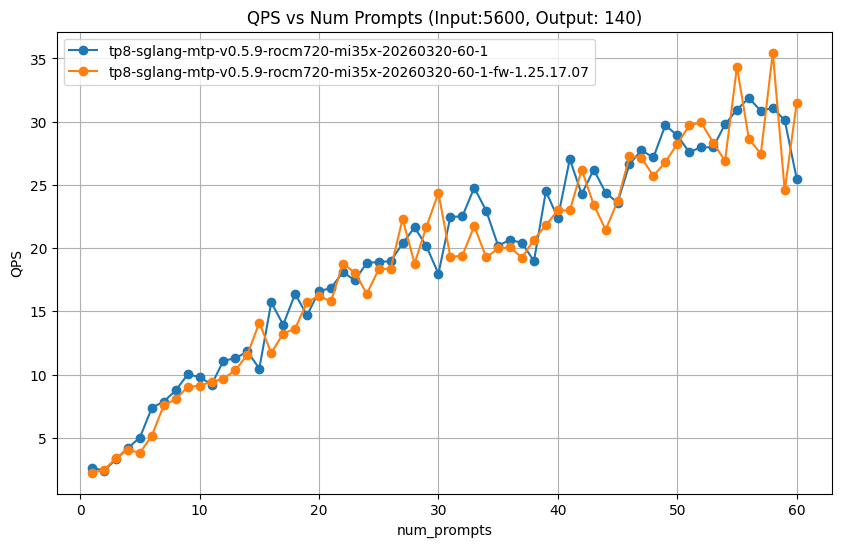

In [11]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_rt = (
        df_subset.groupby('concurrency')['request_throughput']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_rt['concurrency'],
        avg_rt['request_throughput'],
        marker='o',
        label=f'{clean(val)}'
    )

plt.title('QPS vs Num Prompts (Input:5600, Output: 140)')
plt.xlabel('num_prompts')
plt.ylabel('QPS')
plt.grid(True)
plt.legend()

plt.show()

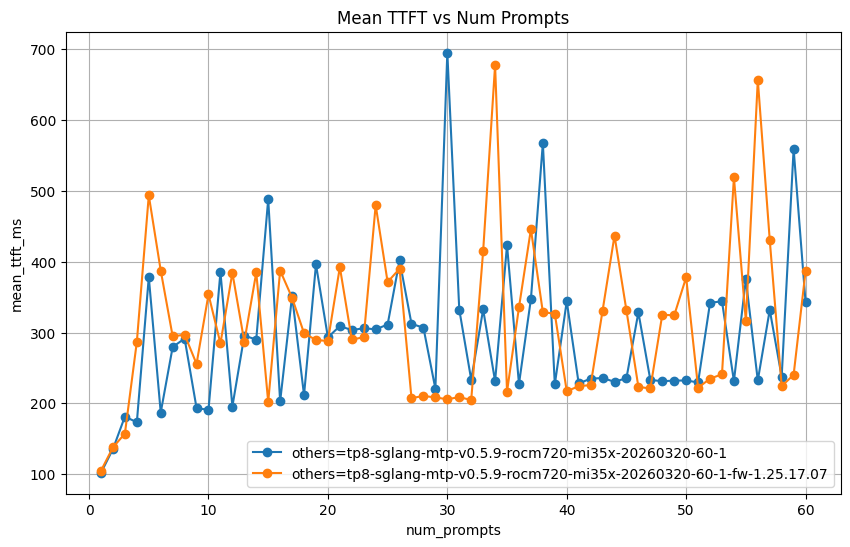

In [12]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_ttft = (
        df_subset.groupby('concurrency')['median_ttft_ms']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_ttft['concurrency'],
        avg_ttft['median_ttft_ms'],
        marker='o',
        label=f'others={clean(val)}'
    )

plt.title('Mean TTFT vs Num Prompts')
plt.xlabel('num_prompts')
plt.ylabel('mean_ttft_ms')
plt.grid(True)
plt.legend()

plt.show()

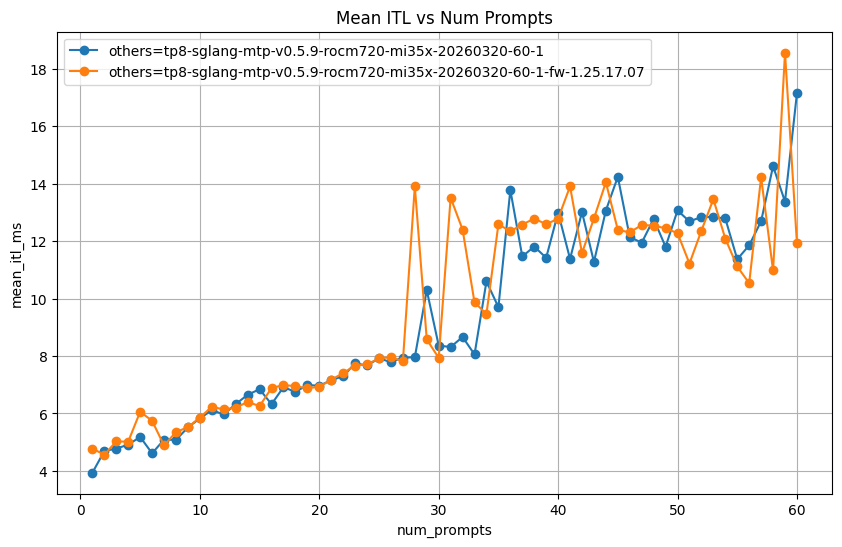

In [13]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_itl = (
        df_subset.groupby('concurrency')['mean_itl_ms']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_itl['concurrency'],
        avg_itl['mean_itl_ms'],
        marker='o',
        label=f'others={clean(val)}'
    )

plt.title('Mean ITL vs Num Prompts')
plt.xlabel('num_prompts')
plt.ylabel('mean_itl_ms')
plt.grid(True)
plt.legend()

plt.show()

In [14]:
df.columns

Index(['mean_tpot_ms', 'total_input_vision_tokens', 'request_throughput',
       'dataset_name', 'random_input_len', 'input_length',
       'total_input_text_tokens', 'p99_e2e_latency_ms', 'std_itl_ms',
       'server_info', 'mean_ttft_ms', 'repeat_no', 'completed', 'model_id',
       'date', 'p99_itl_ms', 'max_output_tokens_per_s', 'duration', 'model',
       'p99_tpot_ms', 'std_e2e_latency_ms', 'concurrency', 'total_throughput',
       'num_prompts', 'max_concurrency', 'total_output_tokens', 'std_tpot_ms',
       'request_rate', 'max_concurrent_num', 'others', 'backend',
       'mean_e2e_latency_ms', 'total_output_tokens_retokenized',
       'output_throughput', 'median_itl_ms', 'label', 'base_url',
       'std_ttft_ms', 'burstiness', 'sharegpt_output_len', 'task_id',
       'max_concurrent_requests', 'p95_itl_ms', 'random_range_ratio',
       'input_throughput', 'hostname', 'request_goodput',
       'total_token_throughput', 'repeats', 'mean_itl_ms', 'median_tpot_ms',
       'accept